<a href="https://colab.research.google.com/github/Sudeepthi-235/MDS-LAB/blob/main/MDS_WEEK_(6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from scipy import stats

df = pd.read_csv('/content/advertising.csv')

print(df.head())
print(df.shape)
print(df.columns)

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
(200, 4)
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [3]:
X = df[['TV']]
y = df['Sales']

print("X:")
print(X.head())

print("\nY:")
print(y.head())

X:
      TV
0  230.1
1   44.5
2   17.2
3  151.5
4  180.8

Y:
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [4]:
model = LinearRegression()

model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 6.974821488229891
Coefficient: 0.055464770469558874


In [5]:
df['Predicted_Sales'] = model.predict(X)

df['Residual'] = df['Sales'] - df['Predicted_Sales']

print(df[['TV', 'Sales', 'Predicted_Sales', 'Residual']].head(10))

      TV  Sales  Predicted_Sales  Residual
0  230.1   22.1        19.737265  2.362735
1   44.5   10.4         9.443004  0.956996
2   17.2   12.0         7.928816  4.071184
3  151.5   16.5        15.377734  1.122266
4  180.8   17.9        17.002852  0.897148
5    8.7    7.2         7.457365 -0.257365
6   57.5   11.8        10.164046  1.635954
7  120.2   13.2        13.641687 -0.441687
8    8.6    4.8         7.451819 -2.651819
9  199.8   15.6        18.056683 -2.456683


In [6]:
print("Mean Residual:", df['Residual'].mean())
print("Standard Deviation of Residuals:", df['Residual'].std())
print("Minimum Residual:", df['Residual'].min())
print("Maximum Residual:", df['Residual'].max())

Mean Residual: -1.652011860642233e-15
Standard Deviation of Residuals: 2.289970243557111
Minimum Residual: -6.443782559035064
Maximum Residual: 5.693235665374846


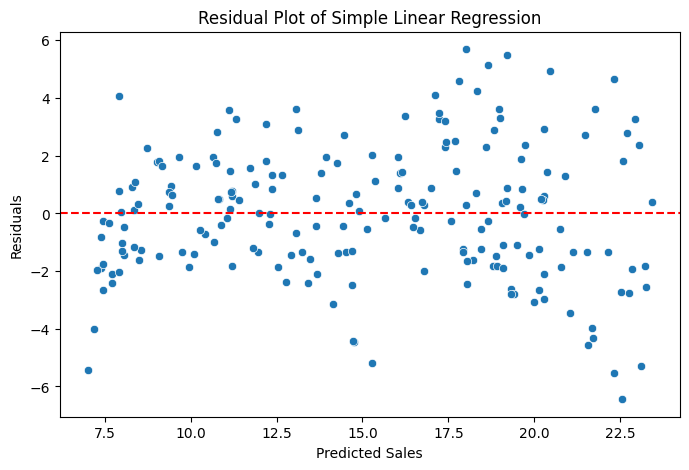

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['Predicted_Sales'], y=df['Residual'])

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot of Simple Linear Regression')

plt.show()

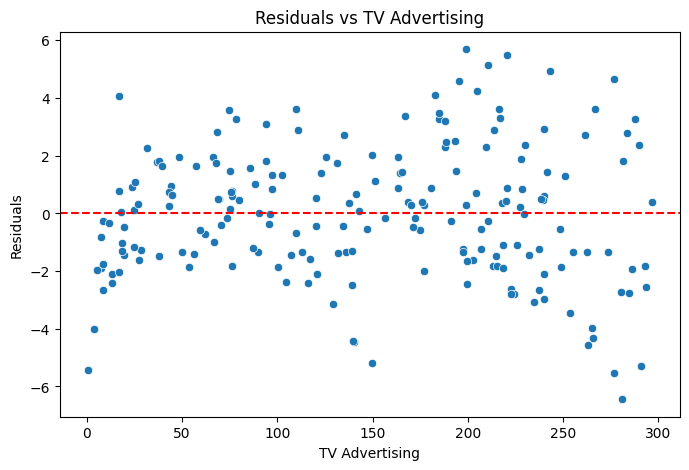

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['TV'], y=df['Residual'])

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('TV Advertising')
plt.ylabel('Residuals')
plt.title('Residuals vs TV Advertising')

plt.show()

In [9]:
df['Standardized_Residual'] = stats.zscore(df['Residual'])

print(df[['TV', 'Sales', 'Residual', 'Standardized_Residual']].head(10))

      TV  Sales  Residual  Standardized_Residual
0  230.1   22.1  2.362735               1.034364
1   44.5   10.4  0.956996               0.418956
2   17.2   12.0  4.071184               1.782294
3  151.5   16.5  1.122266               0.491309
4  180.8   17.9  0.897148               0.392756
5    8.7    7.2 -0.257365              -0.112670
6   57.5   11.8  1.635954               0.716192
7  120.2   13.2 -0.441687              -0.193363
8    8.6    4.8 -2.651819              -1.160920
9  199.8   15.6 -2.456683              -1.075493


In [10]:
outliers = df[abs(df['Standardized_Residual']) > 2]

print("Number of outliers:", len(outliers))

print(outliers[['TV', 'Sales', 'Predicted_Sales',
                'Residual', 'Standardized_Residual']])

Number of outliers: 11
        TV  Sales  Predicted_Sales  Residual  Standardized_Residual
15   195.4   22.4        17.812638  4.587362               2.008268
35   290.7   17.8        23.098430 -5.298430              -2.319561
55   198.9   23.7        18.006764  5.693236               2.492400
58   210.8   23.8        18.666795  5.133205               2.247228
128  220.3   24.7        19.193710  5.506290               2.410558
130    0.7    1.6         7.013647 -5.413647              -2.370001
147  243.2   25.4        20.463854  4.936146               2.160960
150  280.7   16.1        22.543783 -6.443783              -2.820977
157  149.8   10.1        15.283444 -5.183444              -2.269222
175  276.9   27.0        22.333016  4.666984               2.043125
178  276.7   16.8        22.321923 -5.521923              -2.417403


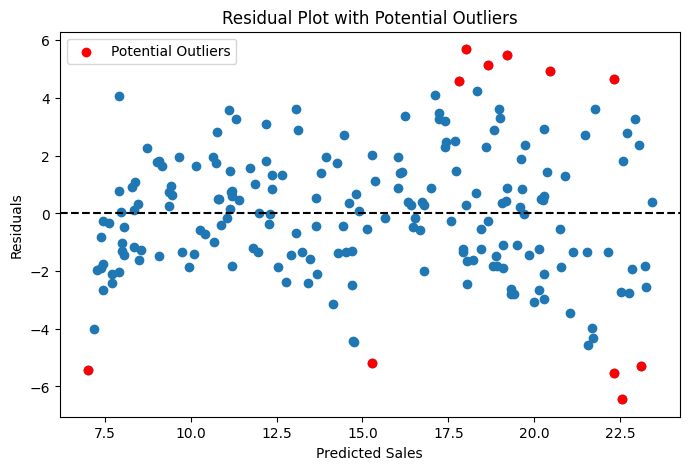

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(df['Predicted_Sales'], df['Residual'])

plt.scatter(
    outliers['Predicted_Sales'],
    outliers['Residual'],
    color='red',
    label='Potential Outliers'
)

plt.axhline(y=0, color='black', linestyle='--')

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot with Potential Outliers')
plt.legend()

plt.show()

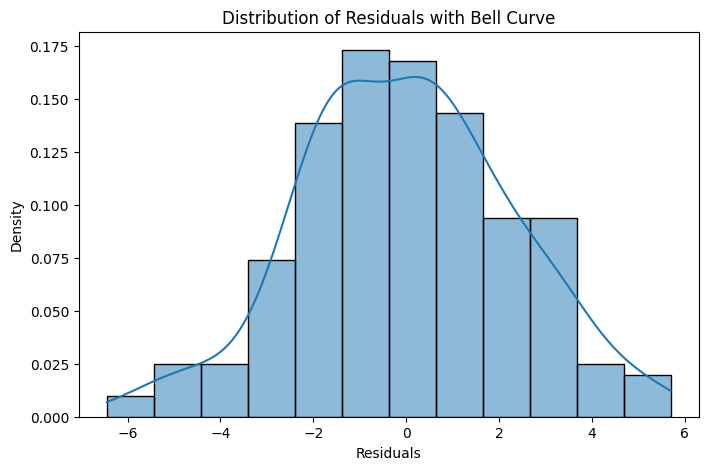

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Residual'],
    kde=True,
    stat='density'
)

plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Distribution of Residuals with Bell Curve')

plt.show()

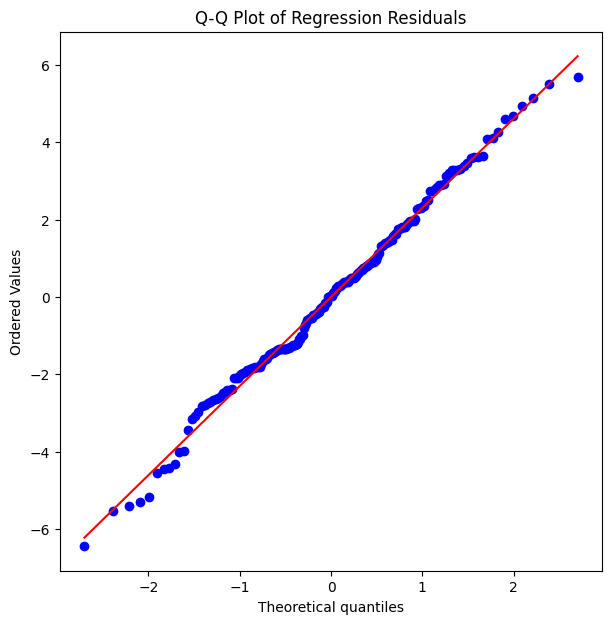

In [13]:
plt.figure(figsize=(7,7))

stats.probplot(df['Residual'], dist="norm", plot=plt)

plt.title('Q-Q Plot of Regression Residuals')

plt.show()

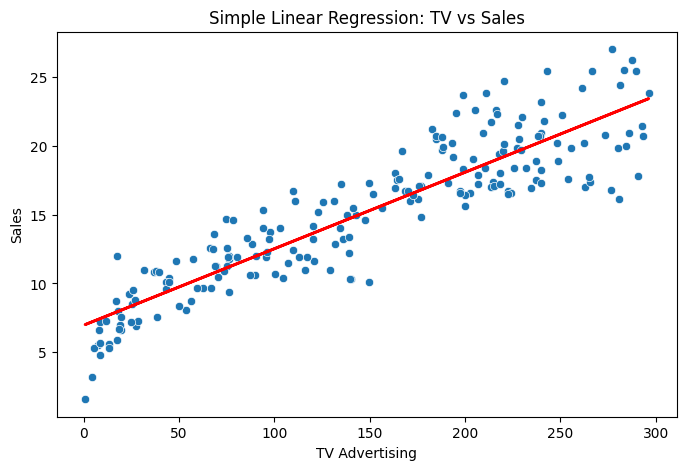

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['TV'], y=df['Sales'])

plt.plot(
    df['TV'],
    df['Predicted_Sales'],
    color='red',
    linewidth=2
)

plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('Simple Linear Regression: TV vs Sales')

plt.show()

In [15]:
print("Regression Equation:")
print(
    "Sales = {:.4f} + {:.4f} × TV".format(
        model.intercept_,
        model.coef_[0]
    )
)

Regression Equation:
Sales = 6.9748 + 0.0555 × TV


In [16]:
r2 = model.score(X, y)

print("R² Score:", r2)

R² Score: 0.8121757029987414


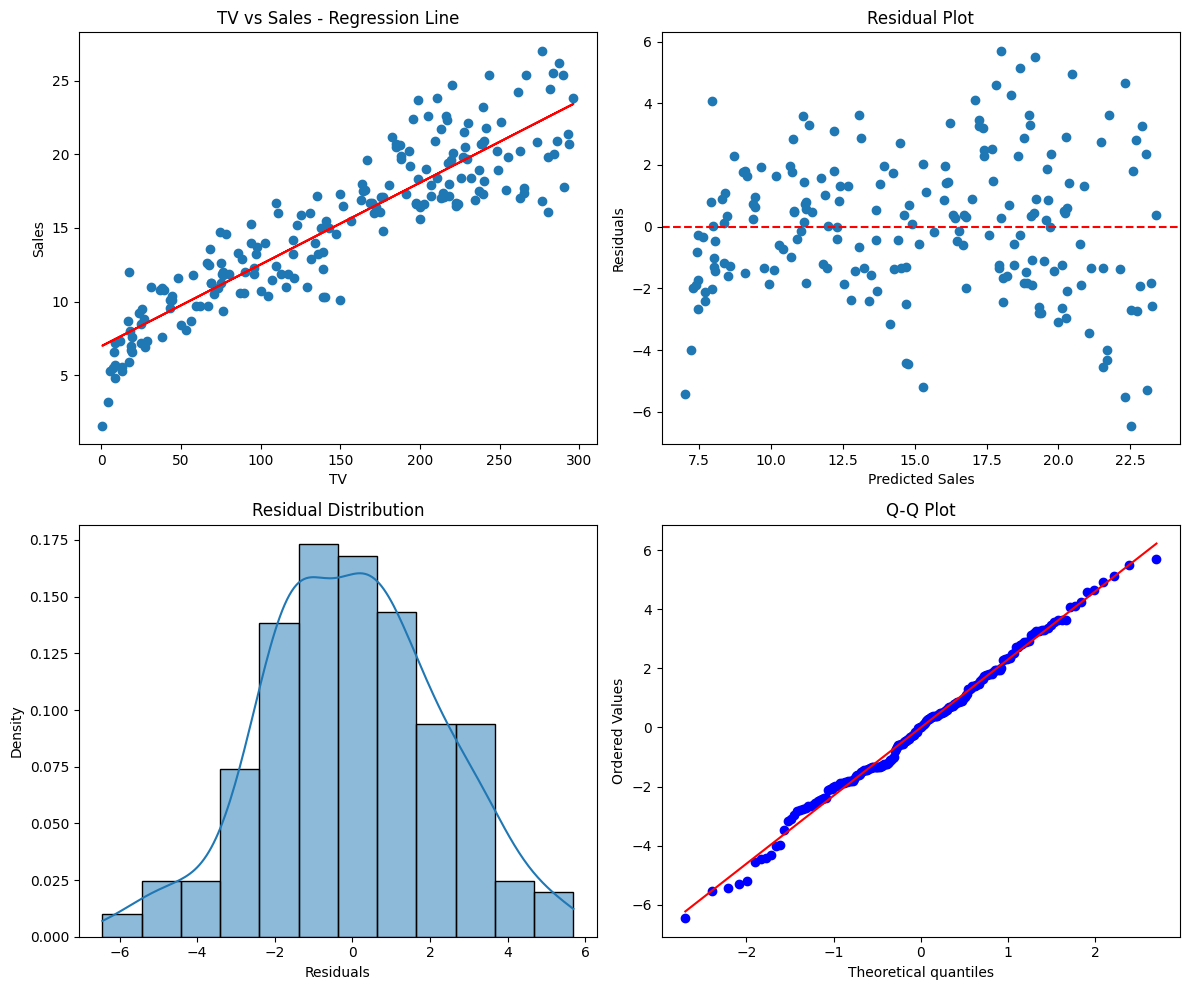

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Regression line
axes[0, 0].scatter(df['TV'], df['Sales'])
axes[0, 0].plot(df['TV'], df['Predicted_Sales'], color='red')
axes[0, 0].set_title('TV vs Sales - Regression Line')
axes[0, 0].set_xlabel('TV')
axes[0, 0].set_ylabel('Sales')

# 2. Residual plot
axes[0, 1].scatter(df['Predicted_Sales'], df['Residual'])
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].set_xlabel('Predicted Sales')
axes[0, 1].set_ylabel('Residuals')

# 3. Bell curve
sns.histplot(df['Residual'], kde=True, stat='density', ax=axes[1, 0])
axes[1, 0].set_title('Residual Distribution')
axes[1, 0].set_xlabel('Residuals')

# 4. Q-Q plot
stats.probplot(df['Residual'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()